# Histograms and binary images

Juan Diego Perez Navarro  
T00067699

In [25]:
import cv2
import numpy as np
from skimage import io
import matplotlib.pyplot as plt

In [39]:
def plot_grayscale(image: np.ndarray, ax=None) -> None:
    if ax is None:
        _, ax = plt.subplots()
    ax.imshow(image, cmap='gray')
    ax.axis('off')

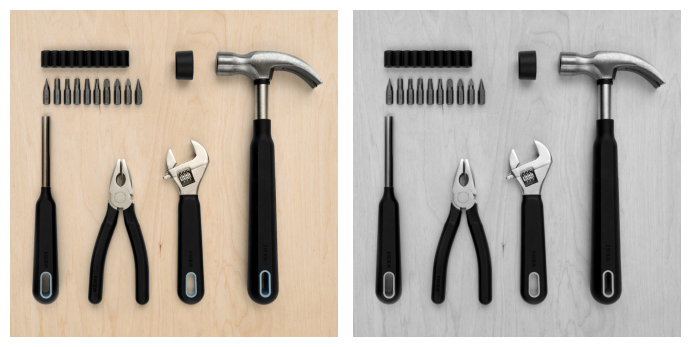

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(7, 6))

IMAGE_PATH = "./images/herramientas.jpeg"
image = io.imread(IMAGE_PATH)  # Shape (1, 1400, 1400, 3)
image = image.reshape(*image.shape[1:])  # Reshape a (1400, 1400, 3)

axes[0].imshow(image)
axes[0].axis('off')

image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(image, (3, 3), 0)
plot_grayscale(blurred, axes[1])

fig.tight_layout()
plt.show()

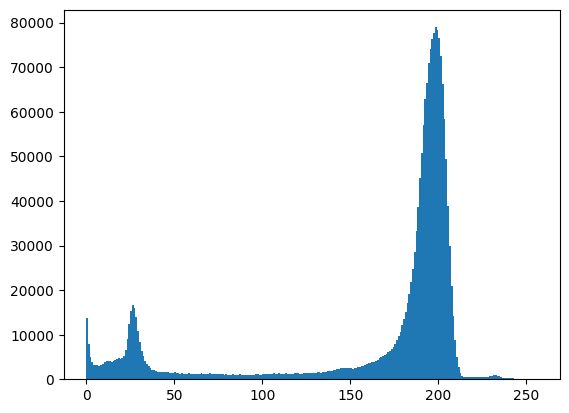

In [8]:
plt.hist(blurred.ravel(), bins=256, range=[0, 256])
plt.show()

Threshold Binary -- 163.0


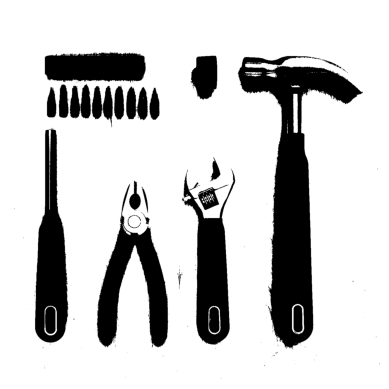

In [20]:
(T, threshImg) = cv2.threshold(blurred, 163, 255, cv2.THRESH_BINARY)
print(f"Threshold Binary -- {T}")
plot_grayscale(threshImg)

Threshold Binary -- 163.0


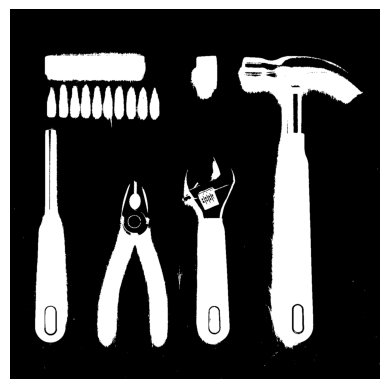

In [21]:
(T, threshInv) = cv2.threshold(blurred, T, 255, cv2.THRESH_BINARY_INV)
print(f"Threshold Binary -- {T}")
plot_grayscale(threshInv)

Herramientas


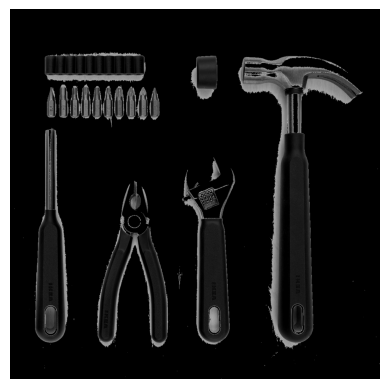

In [24]:
print("Herramientas")
plot_grayscale(cv2.bitwise_and(image, image, mask=threshInv))